In [27]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from tqdm import tqdm

import sys
sys.path.append('/home/agustin/phd/synthesis')
sys.path.append('/home/agustin/phd/miccai/miccai_2025/task_9_global_img_synthesis/code')


import utils.nifti_functions as nfc
import utils.util as util
import utils.functions as fc





In [28]:
class Scheduler:
    def __init__(self, num_timesteps=1000, sample_step=200, s=1., sample_type="linear", objective_type="noise"):
        self.num_timesteps = num_timesteps
        self.s = s
        self.sample_type = sample_type
        self.sample_step = sample_step
        self.objective_type = objective_type

        if self.sample_type == "linear":
            m_min, m_max = 0.001, 0.999
            self.m_t = np.linspace(m_min, m_max, self.num_timesteps)
        elif self.sample_type == "cosine": # not working well
            self.m_t = 1.0075 ** np.linspace(0, self.num_timesteps, self.num_timesteps)
            self.m_t = self.m_t / self.m_t[-1]
            self.m_t[-1] = 0.999
        else:
            raise NotImplementedError
        

        self.m_tminus = np.append(0, self.m_t[:-1])
        self.variance_t = 2. * (self.m_t - self.m_t ** 2) * self.s
        self.variance_tminus = np.append(0., self.variance_t[:-1])
        self.variance_t_tminus = self.variance_t - self.variance_tminus * ((1. - self.m_t) / (1. - self.m_tminus)) ** 2
        self.posterior_variance_t = self.variance_t_tminus * self.variance_tminus / self.variance_t
        self.eta = 1.

        if self.sample_type == 'linear':
            midsteps = np.linspace(self.num_timesteps - 1, 2, self.sample_step - 2, dtype=int)
            self.steps = np.concatenate((midsteps, [1, 0]))
        elif self.sample_type == 'cosine':  # not working well
            t = np.linspace(0, 1, self.sample_step + 1)
            # t = np.linspace(0, 1, self.sample_step)
            steps = np.cos(t * np.pi)  # Cosine decay from 1 to -1
            steps = (steps + 1) / 2 * (self.num_timesteps-1)  # Scale to [0, num_timesteps)
            self.steps = np.round(steps).astype(int)
            self.steps = np.unique(self.steps)
            self.steps = np.flip(np.sort(self.steps))



    def forward_diffusion(self, t, x_0, x_T, noise):
        # def q_sample(...)
        sigma_t = np.sqrt(self.variance_t[t])
        if self.objective_type == "noise":
            objective = noise
        elif self.objective_type == "grad":
            objective = self.m_t[t] * (x_T - x_0) + sigma_t * noise # use this for training
        elif self.objective_type == "ysubx":
            objective = x_T - x_0

        x_next = (1. - self.m_t[t]) * x_0 + self.m_t[t] * x_T + sigma_t * noise
        return x_next, objective
    
    def predict_x0_from_objective(self, t, x_t, x_T, noise):
        if self.objective_type == "noise":
            sigma_t = np.sqrt(self.variance_t[t])
            x_prev = (x_t - self.m_t[t] * x_T - sigma_t * noise) / (1. - self.m_t[t])
        elif self.objective_type == "grad":
            x_prev = x_t - noise
        elif self.objective_type == "ysubx":
            x_prev = x_T - noise
        return x_prev
    
    def backward_diffusion(self, i, x_t, x_T, pred_noise="not_necessary_here" ):
        # def p_sample(...)
        if self.steps[i] == 0:
            
            # t = torch.full((x_t.shape[0],), self.steps[i], device=x_t.device, dtype=torch.long)
            # pred_noise = self.denoise_fn(x_t, timesteps=t, context=None)

            t = self.steps[i]
            x0_recon = self.predict_x0_from_objective(t, x_t, x_T, noise=pred_noise)
            return x0_recon, x0_recon
        
        else:
            # t = torch.full((x_t.shape[0],), self.steps[i], device=x_t.device, dtype=torch.long)
            # n_t = torch.full((x_t.shape[0],), self.steps[i+1], device=x_t.device, dtype=torch.long)
            # objective_recon = self.denoise_fn(x_t, timesteps=t, context=None)

            t = self.steps[i]
            n_t = self.steps[i+1]
            x0_recon = self.predict_x0_from_objective(t, x_t, x_T, noise=pred_noise)

            # start of algorithm 2 using accelerated samplig process
            m_t = self.m_t[t] 
            m_nt = self.m_t[n_t]
            var_t = self.variance_t[t]
            var_nt = self.variance_t[n_t]
 
            sigma2_t = (var_t - var_nt * (1. - m_t) ** 2 / (1. - m_nt) ** 2) * var_nt / var_t
            sigma_t = np.sqrt(sigma2_t) * self.eta

            # noise = torch.randn_like(x_t)
            # Use DDIM instead of DDPM
            noise = np.random.randn(*x_t.shape)
            x_tminus_mean = (1. - m_nt) * x0_recon + m_nt * x_T  \
                            + np.sqrt((var_nt - sigma2_t) / var_t) * (x_t - (1. - m_t) * x0_recon - m_t * x_T)
            return x_tminus_mean + sigma_t * noise, x0_recon
        


    def p_sample_loop(self, x_T, pred_noise_list="not_necessary_here"):
        img = x_T.copy()
        for i in tqdm(range(len(self.steps)), desc=f'sampling loop time step', total=len(self.steps)):
            img, x0_recon = self.backward_diffusion(i=i, x_t=img, x_T=x_T, pred_noise=pred_noise_list[i])
            # x0_recon, img = self.backward_diffusion(i=i, x_t=img, x_T=x_T, pred_noise=pred_noise_list[i])
        return img, x0_recon

    def q_sample_loop(self, x0, x_T):
        imgs = [x0]
        objectives = []
        for i in tqdm(range(self.num_timesteps), desc='q sampling loop', total=self.num_timesteps):
            # t = torch.full((y.shape[0],), i, device=x0.device, dtype=torch.long)
            noise = np.random.randn(*x0.shape)
            img, objective = self.forward_diffusion(i, x0, x_T, noise)
            imgs.append(img)
            objectives.append(objective)
        return imgs, objectives
    
# scheduler = Scheduler(num_timesteps=10, sample_step=10, s=.1, sample_type="linear", objective_type="grad")
# print(len(scheduler.steps))
# print(scheduler.steps)
# print(scheduler.m_t)
# print(scheduler.variance_t)


In [72]:
# Load the image
# base_path = "/home/agustin/phd/miccai/miccai_2025/task_9_global_img_synthesis/code/tests/idea5_bb_diffusion_model/BBDM-main"
# img = np.array(Image.open(f"{base_path}/data/man.png"))
# img2 = np.array(Image.open(f"{base_path}/data/woman.png"))
# img = img[:900, :, :3]
# img2 = img2[:900, :, :3]

# Load brain images
base_path = "/home/agustin/phd/miccai/miccai_2025/task_9_global_img_synthesis/data/reconstructed_good_aff/images"
img = nfc.load_nifti(f"{base_path}/BraTS-GLI-00001-000/BraTS-GLI-00001-000-t1n_rec.nii.gz", transpose=True)[0]
img2 = nfc.load_nifti(f"{base_path}/BraTS-GLI-00001-000/BraTS-GLI-00001-000-t2w_rec.nii.gz", transpose=True)[0]
img = img[:,:,img.shape[2]//2]
img2 = img2[:,:,img2.shape[2]//2]

img = fc.resize_image(img, 256)
img2 = fc.resize_image(img2, 256)
img = util.normalize(img)
img2 = util.normalize(img2)

# create scheduler
scheduler = Scheduler(num_timesteps=5, sample_step=5, s=0.1, sample_type="linear", objective_type="grad")


noisy_imgs_list, objectives_list = scheduler.q_sample_loop(img, img2)
objectives_list = objectives_list[::-1]
rec_img, x0_recon  = scheduler.p_sample_loop(img2, pred_noise_list=objectives_list)

# print(scheduler.steps)

sampling loop time step: 100%|██████████| 5/5 [00:00<00:00, 357.30it/s]


In [ ]:
# own rec x_T -> x0
my_x0_recon = noisy_imgs_list[-1] - objectives_list[0]

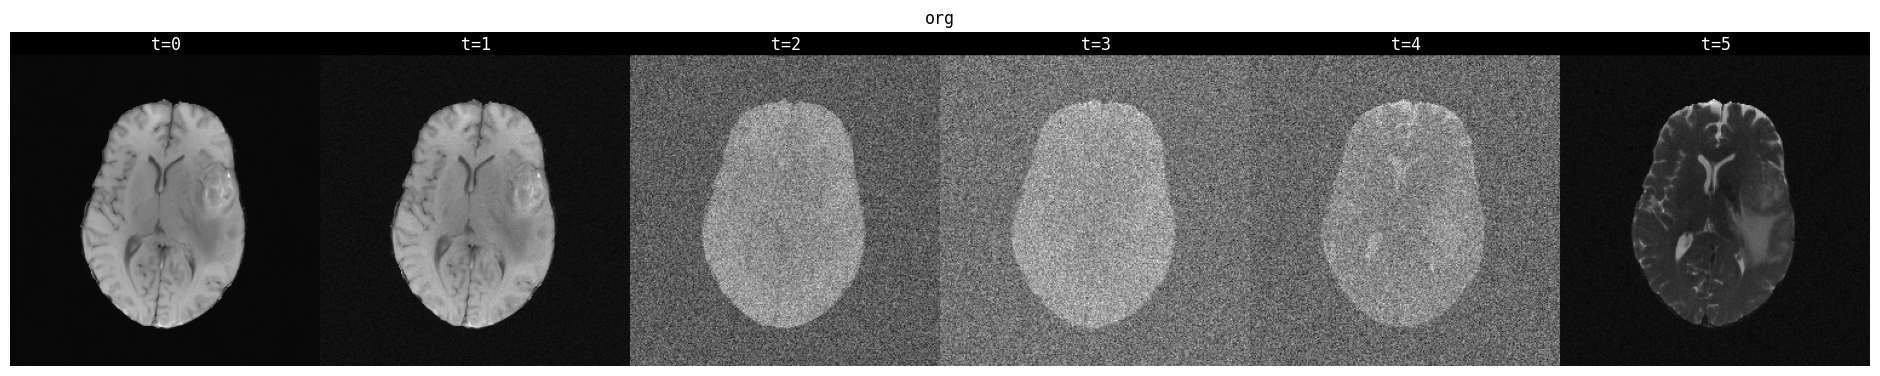

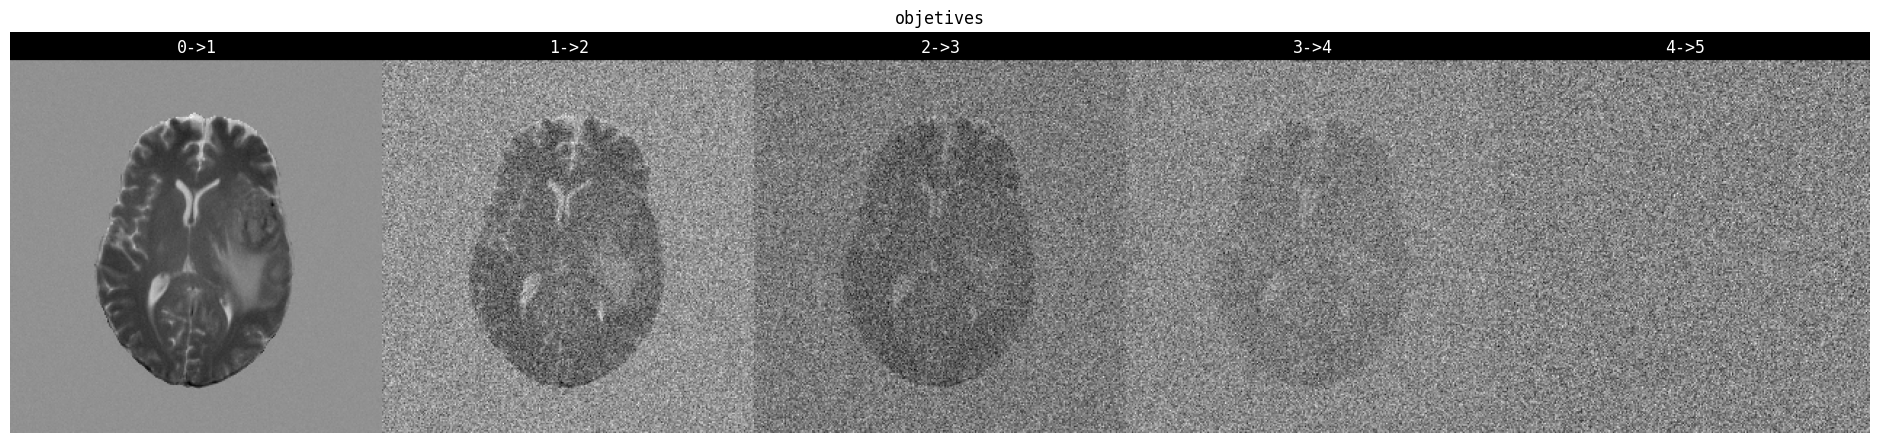

In [73]:
noisy_imgs_to_show = []
for __img in noisy_imgs_list:
    noisy_imgs_to_show.append((util.normalize(__img) * 255.0).astype(np.uint8))

subimg_titles = [f"t={i}" for i in range(len(noisy_imgs_list))]
subobj_titles = [f"{i}->{i+1}" for i in range(len(objectives_list))]
# subimg_titles.append("rec_img")
# noisy_imgs_to_show.append((util.normalize(rec_img) * 255.0).astype(np.uint8))

# subimg_titles.append("x0_recon")
# noisy_imgs_to_show.append((util.normalize(x0_recon) * 255.0).astype(np.uint8))

# subimg_titles.append("my_x0_recon")
# noisy_imgs_to_show.append((util.normalize(my_x0_recon) * 255.0).astype(np.uint8))

figgure_size = (int(10*np.sqrt(len(subimg_titles))), int(3*np.sqrt(len(subimg_titles))))
custom_disposition = (None, len(subimg_titles))
fc.imgshow_list(noisy_imgs_to_show, "org", subimg_titles=subimg_titles, figsize=figgure_size, custom_disposition=custom_disposition)

objectives_to_show = []
for __obj in objectives_list:
    objectives_to_show.append((util.normalize(__obj) * 255.0).astype(np.uint8))

custom_disposition = (None, len(objectives_to_show))
fc.imgshow_list(objectives_to_show,"objetives", figsize=figgure_size, subimg_titles=subobj_titles, custom_disposition=custom_disposition, range_values=(0,255))


# print(len(noisy_imgs_list), len(objectives_list))

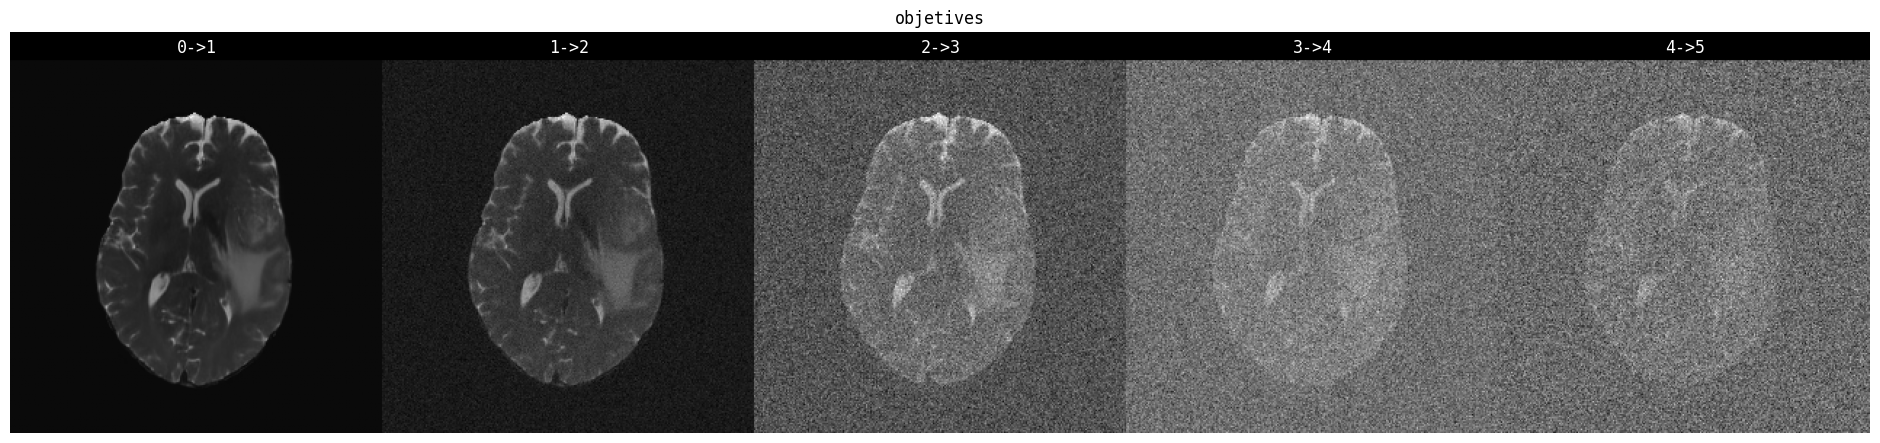

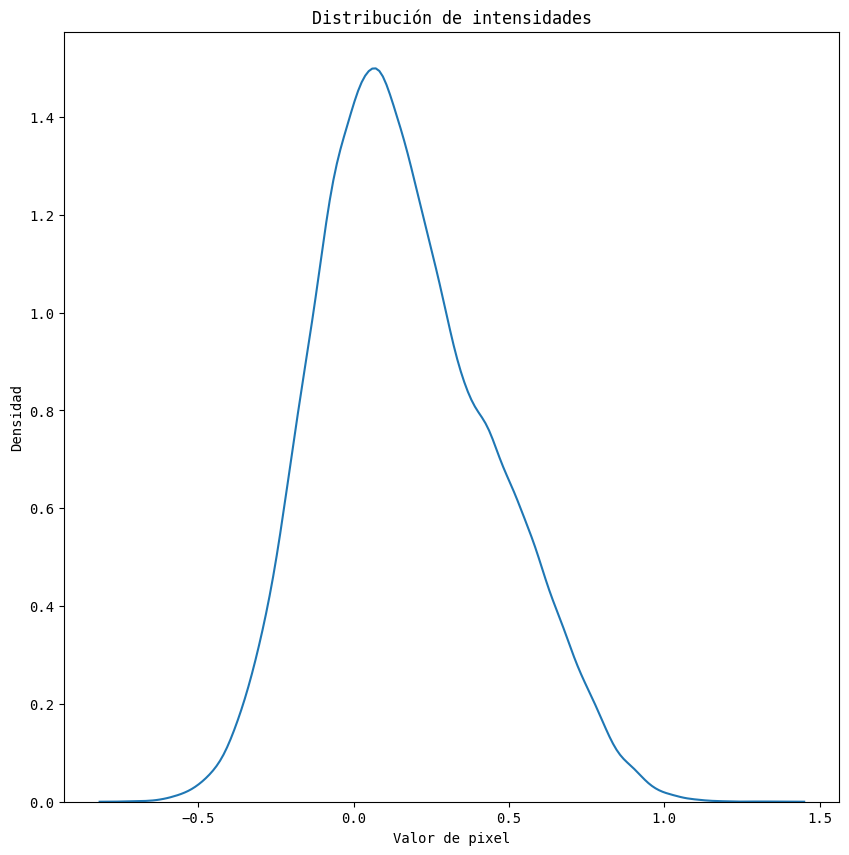

In [74]:
# apply diffusion fordward diffusion porcess to one image
import tests.idea5_bb_diffusion_model.networks_declaration.ddim as ddim
import torch

# img = nfc.load_nifti(f"{base_path}/BraTS-GLI-00001-000/BraTS-GLI-00001-000-t1n_rec.nii.gz", transpose=True)[0]
img = nfc.load_nifti(f"{base_path}/BraTS-GLI-00001-000/BraTS-GLI-00001-000-t2w_rec.nii.gz", transpose=True)[0]
img = torch.from_numpy(img[...,img.shape[2]//2])
nb_diff_steps = 4
scheduler = ddim.DDIMScheduler(num_train_timesteps=nb_diff_steps, beta_start=0.001, beta_end=0.05)
steps_img = [img.numpy()]
for i in range(nb_diff_steps):
    noise = torch.randn(img.shape, device="cpu")
    timesteps = torch.tensor([i], device="cpu").long()
    steps_img.append(scheduler.add_noise(original_samples=img, noise=noise, timesteps=timesteps).numpy())

objectives_to_show = []
for __obj in steps_img:
    objectives_to_show.append((util.normalize(__obj) * 255.0).astype(np.uint8))

custom_disposition = (None, len(objectives_to_show))
fc.imgshow_list(objectives_to_show,"objetives", figsize=figgure_size, subimg_titles=subobj_titles, custom_disposition=custom_disposition, range_values=(0,255))


import matplotlib.pyplot as plt
import seaborn as sns

# Flatten: convertir en vector de intensidades
# pixels = steps_img[0].flatten()
pixels = noisy_imgs_list[2].flatten()

# pixels = pixels[pixels > 0.005]  # Filtrar valores no deseados (opcional)
# Usamos seaborn para ver la distribución como curva (KDE)
plt.figure(figsize=(10, 10))
sns.kdeplot(pixels, bw_adjust=1.0)
plt.title("Distribución de intensidades")
plt.xlabel("Valor de pixel")
plt.ylabel("Densidad")
plt.show()